# Shot Creation Regression Analysis

In [6]:
from __future__ import annotations
import warnings
from pathlib import Path
import polars as pl
import psutil
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, precision_recall_curve
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

warnings.filterwarnings("ignore")

DATA_DIR = Path.cwd().parent/"Additional"
STATSBOMB_DIR = DATA_DIR/"Statsbomb"

# _process = psutil.Process()

df = pl.read_parquet(DATA_DIR / "for_regression.parquet")
df = df.to_pandas()

In [7]:
# shape check
print(df.shape)

# null check
print(df.isnull().sum())

# binary variable creation; was a shot taken during the possession?
df['has_shot'] = (df['n_shots'] > 0).astype(int)
print(df['has_shot'].value_counts(normalize=True))

(642410, 39)
match_id                0
possession_type         0
period                  0
possession              0
OFF_TEAM_ID             0
OFF_MEN_WOMEN           0
OFF_BACKS               0
OFF_MIDFIELDERS         0
OFF_FORWARDS            0
OFF_GOALKEEPER          0
OFF_C0                  0
OFF_C1                  0
OFF_C2                  0
OFF_C3                  0
OFF_C4                  0
OFF_C5                  0
OFF_GK_C0               0
OFF_GK_C1               0
OFF_GK_C2               0
OFF_PLAYERS_ON_PITCH    0
DEF_TEAM_ID             0
DEF_MEN_WOMEN           0
DEF_BACKS               0
DEF_MIDFIELDERS         0
DEF_FORWARDS            0
DEF_GOALKEEPER          0
DEF_C0                  0
DEF_C1                  0
DEF_C2                  0
DEF_C3                  0
DEF_C4                  0
DEF_C5                  0
DEF_GK_C0               0
DEF_GK_C1               0
DEF_GK_C2               0
DEF_PLAYERS_ON_PITCH    0
total_xg                0
n_shots                 0

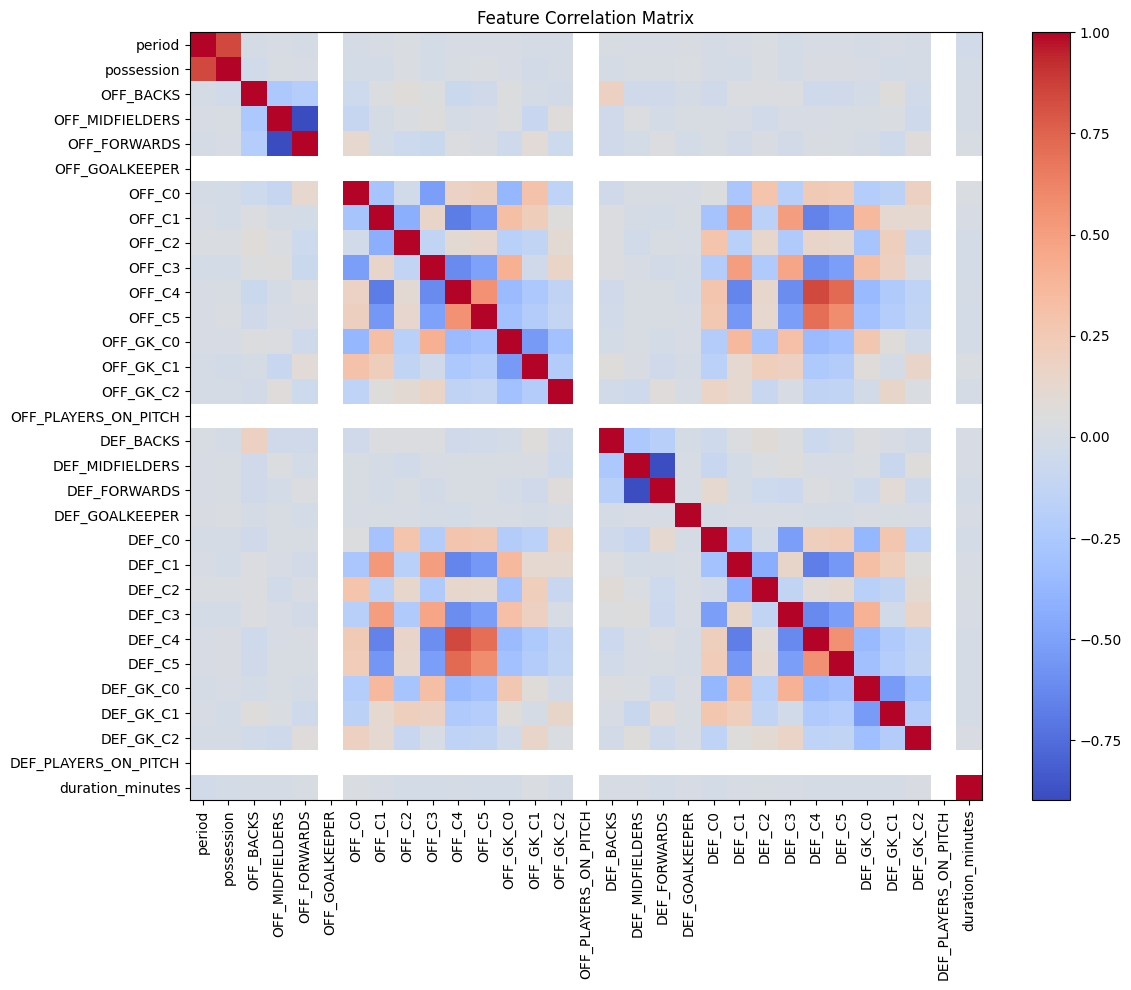

In [8]:
## correlation check

# columns to exclude from numeric features because they are not numbers, or they're response vars
exclude = ['possession_type', 'has_shot', 'total_xg', 'n_shots', 
           'match_id', 'OFF_TEAM_ID', 'DEF_TEAM_ID', 
           'OFF_MEN_WOMEN', 'DEF_MEN_WOMEN']

numeric_features = [col for col in df.columns if col not in exclude]
corr_matrix = df[numeric_features].corr()
plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.xticks(range(len(numeric_features)), numeric_features, rotation=90)
plt.yticks(range(len(numeric_features)), numeric_features)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

* OFF_BACKS and OFF_MIDFIELDERS are strongly negatively correlated (same on defensive side), this is  because player position counts sum to a constant (11)
* Cluster columns C0–C5 show internal correlations, especially C3 with C1/C2, attributed to separate men's/women's clusters
* OFF_PLAYERS_ON_PITCH and DEF_PLAYERS_ON_PITCH are constants and  should be excluded from models
* Offensive and defensive features are largely independent of each other
* duration_minutes is uncorrelated with everything

In [9]:
# create IS_MENS and DIFF features first
df['IS_MENS'] = (df['OFF_MEN_WOMEN'] == 'M').astype(int)
for c in ['C0', 'C1', 'C2', 'C3', 'C4', 'C5']:
    df[f'DIFF_{c}'] = df[f'OFF_{c}'] - df[f'DEF_{c}']
for c in ['GK_C0', 'GK_C1', 'GK_C2']:
    df[f'DIFF_{c}'] = df[f'OFF_{c}'] - df[f'DEF_{c}']

# full VIF, some bad values expected
full_feature_cols = (
    ['duration_minutes', 'IS_MENS',
     'OFF_BACKS', 'OFF_MIDFIELDERS', 'OFF_FORWARDS', 'OFF_GOALKEEPER',
     'DEF_BACKS', 'DEF_MIDFIELDERS', 'DEF_FORWARDS', 'DEF_GOALKEEPER',
     'DIFF_C0', 'DIFF_C1', 'DIFF_C2', 'DIFF_C3', 'DIFF_C4', 'DIFF_C5',
     'DIFF_GK_C0', 'DIFF_GK_C1', 'DIFF_GK_C2']
    + [col for col in df.columns if col.startswith('possession_type_')]
)

X_vif_full = df[full_feature_cols].astype(float)
vif_full = pd.DataFrame({
    'feature': full_feature_cols,
    'VIF': [variance_inflation_factor(X_vif_full.values, i)
            for i in range(X_vif_full.shape[1])]
}).sort_values('VIF', ascending=False)
print(vif_full.to_string())

             feature           VIF
2          OFF_BACKS           inf
4       OFF_FORWARDS           inf
3    OFF_MIDFIELDERS           inf
11           DIFF_C1  1.489125e+04
13           DIFF_C3  1.397922e+04
10           DIFF_C0  8.670701e+03
12           DIFF_C2  5.460574e+03
14           DIFF_C4  5.312698e+03
15           DIFF_C5  2.119693e+03
7    DEF_MIDFIELDERS  2.080110e+03
8       DEF_FORWARDS  2.013439e+03
6          DEF_BACKS  4.424216e+02
17        DIFF_GK_C1  1.227624e+01
16        DIFF_GK_C0  1.129074e+01
18        DIFF_GK_C2  6.472273e+00
9     DEF_GOALKEEPER  1.110469e+00
1            IS_MENS  1.005856e+00
0   duration_minutes  1.001034e+00
5     OFF_GOALKEEPER  0.000000e+00


* OFF_BACKS, OFF_MIDFIELDERS, OFF_FORWARDS are perfectly collinear (inf VIF b/c they sum to a constant w/ OFF_GOALKEEPER).
* All position count columns have extreme VIF, probably should drop all position count columns
* IS_MENS and duration_minutes have VIF around 1.0, meaning they're clean independent features

To sum up, position count columns add nothing beyond what the DIFF cluster features already capture. The variables duration_minutes, IS_MENS, DIFF_C0, DIFF_C1, DIFF_C2, DIFF_C4, DIFF_C5, and possession type dummies should be used going forward. 

### Whittling it Down

In [10]:
df_model = pd.get_dummies(df, columns=['possession_type'], drop_first=True)
df_model['IS_MENS'] = (df_model['OFF_MEN_WOMEN'] == 'M').astype(int)
for c in ['C0', 'C1', 'C2', 'C3', 'C4', 'C5']:
    df_model[f'DIFF_{c}'] = df_model[f'OFF_{c}'] - df_model[f'DEF_{c}']
for c in ['GK_C0', 'GK_C1', 'GK_C2']:
    df_model[f'DIFF_{c}'] = df_model[f'OFF_{c}'] - df_model[f'DEF_{c}']

feature_cols = (
    ['duration_minutes', 'IS_MENS',
     'DIFF_C0', 'DIFF_C1', 'DIFF_C2', 'DIFF_C4', 'DIFF_C5',
     'DIFF_GK_C0', 'DIFF_GK_C1']
    + [col for col in df_model.columns if col.startswith('possession_type_')]
)

X_vif = df_model[feature_cols].astype(float)
vif_data = pd.DataFrame({
    'feature': feature_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)
print(vif_data.to_string())

                                      feature       VIF
1                                     IS_MENS  5.027638
8                                  DIFF_GK_C1  2.758652
7                                  DIFF_GK_C0  2.113517
5                                     DIFF_C4  2.017376
10   possession_type_Defensive Third - Direct  2.011634
15       possession_type_Middle Third - Short  1.983616
9     possession_type_Attacking Third - Short  1.876628
6                                     DIFF_C5  1.762762
4                                     DIFF_C2  1.698636
2                                     DIFF_C0  1.695320
12    possession_type_Defensive Third - Short  1.581094
3                                     DIFF_C1  1.391189
13      possession_type_Middle Third - Direct  1.381711
14     possession_type_Middle Third - Patient  1.185314
0                            duration_minutes  1.067833
11  possession_type_Defensive Third - Patient  1.025776


### Train/Test Split and Scaling

In [11]:
X = df_model[feature_cols].astype(float)
y = df_model['has_shot']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Train set shot rate: {y_train.mean():.4f}")
print(f"Test set shot rate: {y_test.mean():.4f}")

Train set size: (513928, 16)
Test set size: (128482, 16)
Train set shot rate: 0.1205
Test set shot rate: 0.1205


### Model Fit and Initial Results

              precision    recall  f1-score   support

           0       0.92      0.54      0.68    112996
           1       0.16      0.66      0.26     15486

    accuracy                           0.55    128482
   macro avg       0.54      0.60      0.47    128482
weighted avg       0.83      0.55      0.63    128482

ROC-AUC: 0.6314


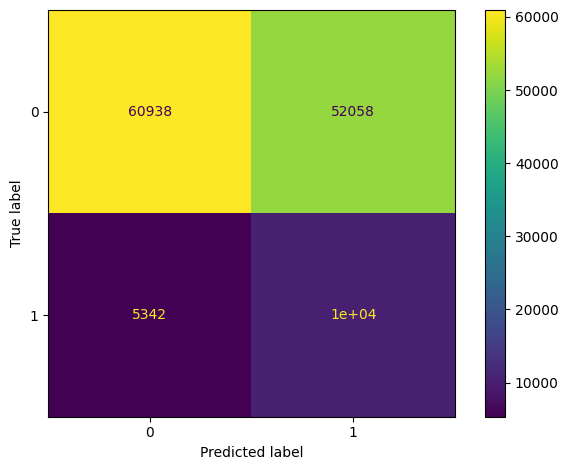

In [12]:
# sklearn fit
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.tight_layout()
plt.show()

Confusion matrix shows 60,938 TNs, 10,000ish TPs, but 52,058 FPs. The balanced weighting is catching shots at the cost of raising a lot of false alarms.

In [13]:
# check shot rates by possession type to see if there's any signal at all
print(df.groupby('possession_type')['has_shot'].mean().sort_values(ascending=False))

# check if duration has any relationship with shots
print(f"\nMean duration - shot possessions: {df[df['has_shot']==1]['duration_minutes'].mean():.4f}")
print(f"Mean duration - no shot possessions: {df[df['has_shot']==0]['duration_minutes'].mean():.4f}")

possession_type
Defensive Third - Patient    0.235792
Attacking Third - Patient    0.210753
Middle Third - Direct        0.200177
Middle Third - Patient       0.166914
Attacking Third - Short      0.139728
Defensive Third - Short      0.133279
Defensive Third - Direct     0.098270
Middle Third - Short         0.063346
Name: has_shot, dtype: float64

Mean duration - shot possessions: 0.3847
Mean duration - no shot possessions: 0.3112


Shot rate by possession type shows some meaningful variation: "Defensive Third - Patient" top @ 23.6%, "Middle Third - Short" lowest @ 6.3%.
Shot possessions have slightly longer mean duration (0.38 min) vs. non-shot possessions (0.31 min)

In [14]:
# find optimal threshold using precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
optimal_threshold = thresholds[f1_scores.argmax()]
print(f"Optimal threshold: {optimal_threshold:.4f}")

# apply optimal threshold
y_pred_adjusted = (y_prob >= optimal_threshold).astype(int)
print(classification_report(y_test, y_pred_adjusted))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

# also try without class_weight but with adjusted threshold
model_default = LogisticRegression(max_iter=1000, random_state=42)
model_default.fit(X_train_scaled, y_train)
y_prob_default = model_default.predict_proba(X_test_scaled)[:, 1]
print(f"\nROC-AUC without class_weight: {roc_auc_score(y_test, y_prob_default):.4f}")

Optimal threshold: 0.5210
              precision    recall  f1-score   support

           0       0.92      0.58      0.71    112996
           1       0.17      0.61      0.26     15486

    accuracy                           0.59    128482
   macro avg       0.54      0.60      0.49    128482
weighted avg       0.83      0.59      0.66    128482

ROC-AUC: 0.6314

ROC-AUC without class_weight: 0.6302


note: genAI used to help explain the following:

**Note on inference model: The statsmodels log. regression below is fit without class weighting, which is common practice for coefficient interpretation. The sklearn model that was used above uses class_weight='balanced' to improve recall on the minority class, but since the ROC-AUC scores are essentially identical with and without class weighting (0.6278 vs 0.6275), the underlying coefficients are not meaningfully affected, so odds ratios should be interpreted as reflecting systematic tendencies in the data rather than the exact decision boundary used for classification.**

### Inference

In [15]:
X_train_sm = sm.add_constant(X_train_scaled)
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.357315
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               has_shot   No. Observations:               513928
Model:                          Logit   Df Residuals:                   513911
Method:                           MLE   Df Model:                           16
Date:                Mon, 13 Apr 2026   Pseudo R-squ.:                 0.02896
Time:                        21:44:56   Log-Likelihood:            -1.8363e+05
converged:                       True   LL-Null:                   -1.8911e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.0670      0.005   -448.759      0.000      -2.076      -2.058
x1             0.0032      0.

In [16]:
feature_names = ['const'] + feature_cols
summary_df = pd.DataFrame({
    'variable': feature_names,
    'coefficient': result.params.values,
    'odds_ratio': np.exp(result.params.values),
    'p_value': result.pvalues.values
}).query("variable != 'const'").sort_values('odds_ratio', ascending=False)
print(summary_df.to_string())

                                     variable  coefficient  odds_ratio        p_value
6                                     DIFF_C4     0.110649    1.117003   2.619943e-70
9                                  DIFF_GK_C1     0.036252    1.036917   4.422149e-07
3                                     DIFF_C0     0.027180    1.027553   1.225255e-06
2                                     IS_MENS     0.016499    1.016635   2.425881e-04
7                                     DIFF_C5     0.013744    1.013838   1.813058e-02
12  possession_type_Defensive Third - Patient     0.008296    1.008330   1.742576e-02
1                            duration_minutes     0.003153    1.003157   3.871224e-01
4                                     DIFF_C1     0.001897    1.001899   7.099054e-01
14      possession_type_Middle Third - Direct    -0.000040    0.999960   9.945006e-01
8                                  DIFF_GK_C0    -0.004273    0.995736   4.964920e-01
15     possession_type_Middle Third - Patient    -0.05

### Cross-Validation

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
print(f"\nCV ROC-AUC scores: {cv_scores}")
print(f"Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


CV ROC-AUC scores: [0.62555201 0.6288651  0.63001248 0.62890455 0.63044686]
Mean: 0.6288 (+/- 0.0017)


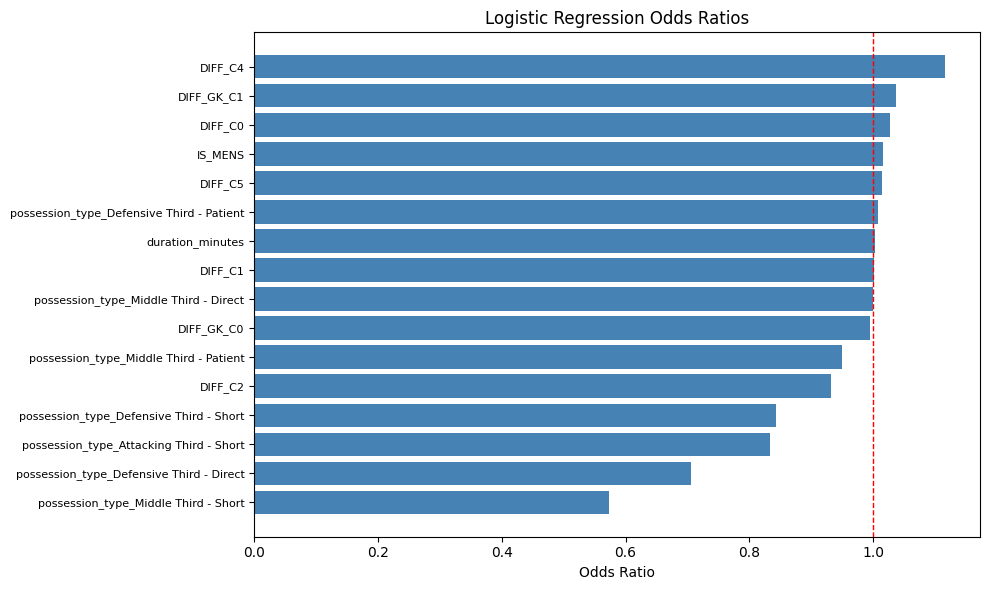

In [18]:
full_plot = summary_df.sort_values('odds_ratio')

plt.figure(figsize=(10, 6))
plt.barh(full_plot['variable'], full_plot['odds_ratio'], color='steelblue')
plt.axvline(x=1, color='red', linestyle='--', linewidth=1)
plt.xlabel('Odds Ratio')
plt.title('Logistic Regression Odds Ratios')
plt.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

* DIFF_GK_C1 is positive and significant (OR 1.037) — having a better GK archetype than the opponent slightly increases shot probability, which is counterintuitive but may reflect that stronger GK teams tend to play more aggressively
* DIFF_GK_C0 is not significant (p=0.496)
* DIFF_C0 has flipped to positive (OR 1.028) — this is a change from previous model worth noting

Insignificant features:

* duration_minutes (p=0.387)
* DIFF_C1 (p=0.710) — previously one of the strongest negative effects, now insignificant
* DIFF_GK_C0 (p=0.496)
* possession_type_Middle Third - Direct (p=0.995)